# PHASE 0.6 — The decisive test

## What Phase 0.5 established, on your real data

| Check | Before | After | Verdict |
|---|---|---|---|
| `brightness_drift` saturation @ sev 5 | 0.327 | **0.0002**, flat across all severities | fixed |
| `lens_contamination` monotonicity | −0.65 | **+1.00** | fixed |
| All 12 severity ladders | 1 failing | **12/12 PASS**, min 0.90 | fixed |
| Near-duplicate detector validity (NEU) | pHash: invalid | embeddings: **AUROC 0.809**, 0 cross-class flags | usable |
| Quality → label leakage, uncorrected | 0.737 | — | — |
| Quality → label leakage, class-standardised @ 0.909 predictor | — | **0.234** (chance 0.167) | WARN |

The mechanism transfers from the synthetic experiment to real data. Leakage falls from 0.737 to
0.234 at a realistic predictor accuracy, and to 0.131 — *below* chance — with oracle labels,
while the severity signal is unchanged or slightly better (0.458 → 0.468).

**One synthetic prediction was wrong.** The relative descriptor scored a *higher* severity signal
than the absolute one on synthetic textures (0.324 vs 0.236). On real NEU it is *lower*
(0.373 vs 0.458), and equally leaky. It loses on both axes and is dropped from here on.

---

## Two things Phase 0.5 did not do

**§5.1 promised a joint test and never ran it.** The cell titled *"Does the corrected descriptor
still buy anything?"* defines `ScalarTemperature`, `LinearQCTS`, `MLPQCTS` and the metrics — and
then stops. It has `execution_count=9` and zero outputs. The pivotal question was never tested.
That was an error in the patch notebook, and this notebook exists to close it.

**The near-duplicate flags were never checked for over-grouping.** The embedding detector flagged
2,093 pairs among 1,800 NEU images. That is the same shape of risk that pHash created on Magnetic
Tile: constraining transitively-linked pairs into shared folds can collapse a class into one or
two folds. §2 measures the connected components before anything is constrained.

---

## The question this notebook answers

Everything now rests on one thing. Phase 0's sanity run left it undetermined:

> Does conditioning the temperature on image quality beat a **single scalar temperature**? And if
> it does, is the gain coming from *quality* — or from the class information the descriptor still
> carries?

Seven calibrators, all fitted on identical data except where stated:

| Code | Temperature model | Fitted on | Purpose |
|---|---|---|---|
| C0 | none | — | uncalibrated reference |
| C1 | scalar | clean validation | the naive baseline |
| C2 | scalar | augmented validation | **the fair baseline** |
| C3 | MLP on raw *q* | augmented validation | Phase 0 showed this fails; included for the ablation |
| C4 | linear on raw *q* | augmented validation | quality-conditioned, uncorrected |
| **C5** | **linear on one-hot predicted class** | augmented validation | **content-only control — no quality information at all** |
| C6 | linear on class-standardised *q* | augmented validation | **the proposed method** |

C5 is what makes this decisive. It has access to exactly the class information the descriptor
leaks, and *nothing else* — no sharpness, no noise, no blockiness. So:

* **C6 must beat C2**, or quality-conditioning buys nothing over one scalar and there is no method
  contribution.
* **C6 must beat C5**, or whatever gain exists is content-conditioning wearing a quality costume,
  and the method must be renamed and re-argued.

Both comparisons are tested on held-out corruption families the calibrators never saw, with a
paired bootstrap over test images.

**A null result here is a legitimate outcome.** SDI-C, the split protocol, the leakage
precondition and the corrected severity ladders all stand on their own. If C6 loses, the paper
becomes a benchmark-and-audit paper — publishable, just differently framed. What is not
acceptable is discovering it in review.

## 0. Self-contained core module

Phase 0.5 wrote `sdic_core_v2.py` into `/content`, which Colab deletes between runtimes. This
notebook therefore carries its own byte-identical copy and writes it if absent, verifying the
SHA-256 against the audited version so the two cannot silently drift.

In [ ]:
CORE_V2 = r"""
import math, hashlib
import numpy as np, cv2

def _clip(x): return np.clip(x, 0, 1)
def _mask3(mask, x): return mask[..., None] if x.ndim == 3 else mask

# ------------------------------------------------------------------ optics --
def defocus_blur(x, s):
    r = [1, 2, 3, 5, 7][s-1]
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1)).astype(np.float32)
    return _clip(cv2.filter2D(x, -1, k/k.sum()))

def motion_blur(x, s):
    ksz = [5, 9, 13, 19, 25][s-1]
    ang = np.random.uniform(0, 180)
    k = np.zeros((ksz, ksz), np.float32); k[ksz//2, :] = 1.0
    M = cv2.getRotationMatrix2D((ksz/2-.5, ksz/2-.5), ang, 1.0)
    k = cv2.warpAffine(k, M, (ksz, ksz))
    return _clip(cv2.filter2D(x, -1, k/k.sum()))

def vignetting(x, s):
    st = [0.15, 0.30, 0.45, 0.62, 0.80][s-1]
    h, w = x.shape[:2]; yy, xx = np.mgrid[0:h, 0:w]
    r = np.sqrt(((xx-w/2)/(w/2))**2 + ((yy-h/2)/(h/2))**2)
    m = np.clip(1 - st*np.clip(r-0.4, 0, None)/0.6, 0, 1).astype(np.float32)
    return _clip(x * _mask3(m, x))

def lens_contamination(x, s):
    n = [3, 7, 13, 22, 34][s-1]; h, w = x.shape[:2]
    blurred = cv2.GaussianBlur(x, (0, 0), sigmaX=max(1.0, min(h, w)/40))
    mask = np.zeros((h, w), np.float32)
    for _ in range(n):
        c = (np.random.randint(0, w), np.random.randint(0, h))
        rad = np.random.randint(max(2, int(0.015*w)), max(4, int(0.07*w)))
        cv2.circle(mask, c, rad, 1.0, -1, lineType=cv2.LINE_AA)
    mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=max(1.0, min(h, w)/60))
    m = _mask3(mask, x)                       # guard: 2-D input used to broadcast to (H,W,W)
    return _clip((x*(1-m) + blurred*m) * (1 - 0.25*m))

def vibration_jitter(x, s):
    amp = [0.6, 1.4, 2.6, 4.2, 6.5][s-1]; h, w = x.shape[:2]
    dx, dy = np.random.uniform(-amp, amp, 2)
    out = cv2.warpAffine(x, np.float32([[1, 0, dx], [0, 1, dy]]), (w, h),
                         flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    ksz = int(max(3, 2*round(amp)+1))
    k = np.zeros((ksz, ksz), np.float32); k[ksz//2, :] = 1.0
    M2 = cv2.getRotationMatrix2D((ksz/2-.5, ksz/2-.5), math.degrees(math.atan2(dy, dx)), 1.0)
    k = cv2.warpAffine(k, M2, (ksz, ksz))
    return _clip(cv2.filter2D(out, -1, k/max(k.sum(), 1e-8)))

# ------------------------------------------------------------------ sensor --
def gaussian_noise(x, s):
    return _clip(x + np.random.normal(0, [0.03, 0.06, 0.10, 0.16, 0.24][s-1], x.shape))

def shot_noise(x, s):
    lam = [80, 35, 15, 7, 3][s-1]
    return _clip(np.random.poisson(x*lam)/float(lam))

def scanline_banding(x, s):
    amp = [0.03, 0.06, 0.11, 0.17, 0.25][s-1]; h = x.shape[0]
    period = np.random.uniform(3, 22); phase = np.random.uniform(0, 2*np.pi)
    b = (1 + amp*np.sin(2*np.pi*np.arange(h)/period + phase)).astype(np.float32)
    return _clip(x * (b[:, None, None] if x.ndim == 3 else b[:, None]))

# ------------------------------------------------------------- photometric --
def illumination_gradient(x, s):
    st = [0.10, 0.20, 0.32, 0.46, 0.62][s-1]; h, w = x.shape[:2]
    ang = np.random.uniform(0, 2*np.pi); yy, xx = np.mgrid[0:h, 0:w]
    u = (xx/w-.5)*np.cos(ang) + (yy/h-.5)*np.sin(ang)
    g = (1 + st*u/(np.abs(u).max()+1e-8)).astype(np.float32)
    return _clip(x * _mask3(g, x))

def brightness_drift(x, s):
    # v2: gamma instead of an additive offset. Gamma maps [0,1] -> [0,1] and CANNOT clip.
    # v1 saturated 36.8% of pixels at severity 5 on Magnetic Tile, which destroyed dynamic
    # range rather than shifting brightness and made the top of the ladder meaningless.
    g = [1.12, 1.26, 1.45, 1.72, 2.05][s-1]
    if np.random.rand() < 0.5: g = 1.0/g
    return _clip(np.power(_clip(x), g))

def contrast_loss(x, s):
    g = [0.80, 0.65, 0.50, 0.36, 0.24][s-1]
    m = x.mean(axis=(0, 1), keepdims=True)
    return _clip((x-m)*g + m)

# ---------------------------------------------------------------- pipeline --
def jpeg_compression(x, s):
    q = [70, 50, 32, 18, 9][s-1]
    src = (x[..., ::-1]*255).astype(np.uint8) if x.ndim == 3 else (x*255).astype(np.uint8)
    _, enc = cv2.imencode(".jpg", src, [int(cv2.IMWRITE_JPEG_QUALITY), q])
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR if x.ndim == 3 else cv2.IMREAD_GRAYSCALE)
    return (dec[..., ::-1] if x.ndim == 3 else dec).astype(np.float32)/255.

CORRUPTIONS = {
    "defocus_blur": defocus_blur, "motion_blur": motion_blur, "vignetting": vignetting,
    "lens_contamination": lens_contamination, "vibration_jitter": vibration_jitter,
    "gaussian_noise": gaussian_noise, "shot_noise": shot_noise,
    "scanline_banding": scanline_banding, "illumination_gradient": illumination_gradient,
    "brightness_drift": brightness_drift, "contrast_loss": contrast_loss,
    "jpeg": jpeg_compression,
}
TRAIN_FAMILIES = ["defocus_blur", "gaussian_noise", "illumination_gradient",
                  "jpeg", "lens_contamination", "scanline_banding"]
TEST_FAMILIES  = ["motion_blur", "shot_noise", "brightness_drift",
                  "contrast_loss", "vignetting", "vibration_jitter"]
SEVERITIES = [1, 2, 3, 4, 5]
CONDITIONS = [("clean", 0)] + [(f, s) for f in CORRUPTIONS for s in SEVERITIES]


def corruption_seed(image_id, family, severity=None):
    # Depends on (image_id, family) only, NOT severity: nuisance parameters (blur angle,
    # banding period, blob positions, gradient orientation) stay fixed so that severity is
    # the sole varying factor. Seeding on severity too made scanline_banding score 0.20.
    h = hashlib.sha256(f"{image_id}|{family}".encode()).digest()
    return int.from_bytes(h[:4], "little")


def apply_corruption(img_u8, family, severity, image_id=None, seed=None):
    if family == "clean":
        return img_u8
    if seed is None and image_id is not None:
        seed = corruption_seed(image_id, family)
    st = None
    if seed is not None:
        st = np.random.get_state(); np.random.seed(seed % (2**32))
    try:
        out = CORRUPTIONS[family](img_u8.astype(np.float32)/255., severity)
    finally:
        if st is not None: np.random.set_state(st)
    return (np.clip(out, 0, 1)*255).astype(np.uint8)


# ------------------------------------------------------- quality descriptors -
def _gray(im):
    g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY) if im.ndim == 3 else im
    return g.astype(np.float32)/255.

def _sharp(im): return float(cv2.Laplacian(_gray(im), cv2.CV_32F).var())

def _noise(im):
    g = _gray(im); h, w = g.shape
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], np.float32)
    return float(np.abs(cv2.filter2D(g, -1, M)).sum()*math.sqrt(math.pi/2) /
                 (6*max(w-2, 1)*max(h-2, 1)))

def _block(im):
    dh = np.abs(np.diff(_gray(im), axis=1))
    on = dh[:, 7::8].mean() if dh.shape[1] > 8 else 0.0
    return float(on/(dh.mean()+1e-8) - 1.0)

def _hf(im):
    g = _gray(im); f = np.abs(np.fft.fftshift(np.fft.fft2(g))); h, w = g.shape
    cy, cx = h//2, w//2; r = max(4, min(h, w)//8)
    return float(1.0 - f[cy-r:cy+r, cx-r:cx+r].sum()/(f.sum()+1e-8))


def quality_descriptor(img_u8):
    # 8-d ABSOLUTE no-reference descriptor (unchanged from v1).
    g = _gray(img_u8); h, w = g.shape
    if img_u8.ndim == 3:
        rg = img_u8[..., 0].astype(np.float32) - img_u8[..., 1]
        yb = .5*(img_u8[..., 0].astype(np.float32) + img_u8[..., 1]) - img_u8[..., 2]
        colour = float((np.sqrt(rg.std()**2 + yb.std()**2)
                        + .3*np.sqrt(rg.mean()**2 + yb.mean()**2))/255.)
    else:
        colour = 0.0
    cen = g[h//4:3*h//4, w//4:3*w//4]
    per = (g.sum()-cen.sum())/max(g.size-cen.size, 1)
    v = np.array([math.log1p(max(_sharp(img_u8), 0.)*1e3), _hf(img_u8),
                  math.log1p(max(_noise(img_u8), 0.)*1e3), _block(img_u8),
                  float(g.mean()), float(g.std()), colour,
                  float(cen.mean()/(per+1e-8))], np.float32)
    return np.nan_to_num(v, nan=0., posinf=0., neginf=0.)


def quality_descriptor_relative(img_u8):
    # 8-d PERTURBATION-RESPONSE descriptor: how much does a statistic move when a known
    # perturbation is applied? Higher severity signal than the absolute set (0.324 vs 0.236
    # on the synthetic benchmark) but NO reduction in class leakage on its own -- ratios
    # remove the absolute texture level, not the spectral shape. Use with class-conditional
    # standardisation, never alone.
    g8 = (_gray(img_u8)*255).astype(np.uint8); eps = 1e-8
    b = cv2.GaussianBlur(g8, (0, 0), 1.5)
    dn = cv2.resize(cv2.resize(g8, (max(2, g8.shape[1]//2), max(2, g8.shape[0]//2)),
                               interpolation=cv2.INTER_AREA),
                    (g8.shape[1], g8.shape[0]), interpolation=cv2.INTER_LINEAR)
    rn = np.random.default_rng(12345)
    nz = np.clip(g8.astype(np.float32) + rn.normal(0, 12, g8.shape), 0, 255).astype(np.uint8)
    _, e = cv2.imencode(".jpg", g8, [int(cv2.IMWRITE_JPEG_QUALITY), 40])
    jp = cv2.imdecode(e, cv2.IMREAD_GRAYSCALE)
    kh = np.zeros((9, 9), np.float32); kh[4, :] = 1/9.
    hb = cv2.filter2D(g8.astype(np.float32), -1, kh).astype(np.uint8)
    vb = cv2.filter2D(g8.astype(np.float32), -1, kh.T).astype(np.uint8)
    x = g8.astype(np.float32)/255.
    v = np.array([
        math.log((_sharp(g8)+eps)/(_sharp(b)+eps)),
        math.log((_sharp(g8)+eps)/(_sharp(dn)+eps)),
        math.log((_noise(nz)+eps)/(_noise(g8)+eps)),
        _block(jp) - _block(g8),
        float(((x+0.25) > 1.0).mean() + ((x-0.25) < 0.0).mean()),
        abs(math.log((_sharp(hb)+eps)/(_sharp(vb)+eps))),
        math.log((_hf(g8)+eps)/(_hf(b)+eps)),
        math.log((_gray(g8).std()+eps)/(_gray(b).std()+eps)),
    ], np.float32)
    return np.nan_to_num(v, nan=0., posinf=0., neginf=0.)


QUALITY_NAMES = ["sharpness", "hf_energy", "noise", "blockiness",
                 "luminance_mean", "luminance_std", "colourfulness", "vignette_ratio"]
RELATIVE_NAMES = ["blur_headroom", "resolution_headroom", "noise_headroom",
                  "compression_headroom", "clipping_headroom", "blur_anisotropy",
                  "hf_retention", "contrast_retention"]
QUALITY_DIM = 8


class ClassConditionalStandardiser:
    # z = (q - mu_c) / sigma_c, with mu_c and sigma_c estimated on DEVELOPMENT data only.
    #
    # Rationale: degradation is relative. A blurry-looking crazing image and a sharp-looking
    # patches image can have identical absolute sharpness; what makes one degraded is that it
    # is blurrier than crazing images normally are. Removing the class-conditional mean strips
    # the content component and leaves the deviation-from-typical -- which is the degradation.
    #
    # At test time c is the model's own prediction. There is no feedback loop: a per-image
    # scalar temperature cannot change the argmax, so the prediction is fixed before the
    # calibrator runs.
    def __init__(self, n_classes):
        self.n_classes = n_classes; self.mu = None; self.sd = None

    def fit(self, q, y):
        d = q.shape[1]
        self.mu = np.zeros((self.n_classes, d), np.float32)
        self.sd = np.ones((self.n_classes, d), np.float32)
        gm, gs = q.mean(0), q.std(0) + 1e-6
        for c in range(self.n_classes):
            m = (y == c)
            if m.sum() >= 5:                 # fall back to global stats for tiny classes
                self.mu[c] = q[m].mean(0); self.sd[c] = q[m].std(0) + 1e-6
            else:
                self.mu[c] = gm; self.sd[c] = gs
        return self

    def transform(self, q, y_pred):
        y_pred = np.asarray(y_pred).astype(int)
        return ((q - self.mu[y_pred]) / self.sd[y_pred]).astype(np.float32)
"""
print(f"embedded core module: {len(CORE_V2.splitlines())} lines")

embedded core module: 246 lines


## 1. Setup

In [ ]:
#@title Dependencies and core module
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "timm==1.0.11", "scikit-learn==1.5.2", "opencv-python-headless==4.10.0.84",
                "pandas==2.2.3", "kagglehub", "tqdm"], check=True)

import os, json, math, time, random, hashlib, warnings
from collections import defaultdict, Counter
from pathlib import Path
import numpy as np, pandas as pd, cv2
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import timm
warnings.filterwarnings("ignore")

SEED = 20260821
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ROOT = Path("/content/sdic"); OUT = ROOT/"phase0"; OUT.mkdir(parents=True, exist_ok=True)

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

sys.path.insert(0, str(ROOT))

# Colab wipes /content between runtimes, so a module written by Phase 0.5 in an earlier
# session will not be here. Depending on it was a design error; this notebook now carries
# its own byte-identical copy and bootstraps itself.
_target = ROOT/"sdic_core_v2.py"
_want = hashlib.sha256(CORE_V2.encode()).hexdigest()
if not _target.exists():
    _target.write_text(CORE_V2)
    print(f"sdic_core_v2.py not present (fresh runtime) -> written, sha256 {_want[:16]}")
elif hashlib.sha256(_target.read_text().encode()).hexdigest() != _want:
    print("WARNING: an existing sdic_core_v2.py differs from the audited copy.")
    print(f"  on disk  {hashlib.sha256(_target.read_text().encode()).hexdigest()[:16]}")
    print(f"  embedded {_want[:16]}")
    print("  overwriting with the audited copy so this test is reproducible.")
    _target.write_text(CORE_V2)
else:
    print(f"sdic_core_v2.py present and matches the audited copy, sha256 {_want[:16]}")

import importlib, sdic_core_v2
importlib.reload(sdic_core_v2)
from sdic_core_v2 import (CORRUPTIONS, TRAIN_FAMILIES, TEST_FAMILIES, SEVERITIES,
                          apply_corruption, quality_descriptor,
                          ClassConditionalStandardiser, QUALITY_NAMES, QUALITY_DIM)
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE=="cuda" else "cpu")
print(f"{len(TRAIN_FAMILIES)} train families, {len(TEST_FAMILIES)} held-out test families")

sdic_core_v2.py not present (fresh runtime) -> written, sha256 fd8e3c534562f9d2
device: cuda | Tesla T4
6 train families, 6 held-out test families


In [ ]:
#@title Index NEU
import kagglehub
NEU_ROOT = Path(kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database"))
neu = [p for p in sorted(NEU_ROOT.rglob("*.jpg"))
       if p.parent.name.lower() not in {"train","validation","images","annotations"}]
labels = np.array([p.parent.name for p in neu])
LUT = {n:i for i,n in enumerate(sorted(set(labels)))}
y_all = np.array([LUT[l] for l in labels])
print(f"{len(neu)} images, {len(LUT)} classes: {dict(Counter(labels))}")
def rd(p): return cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)

100%|██████████| 26.4M/26.4M [00:01<00:00, 22.4MB/s]

Extracting files...


1800 images, 6 classes: {np.str_('crazing'): 300, np.str_('inclusion'): 300, np.str_('patches'): 300, np.str_('pitted_surface'): 300, np.str_('rolled-in_scale'): 300, np.str_('scratches'): 300}


## 2. Near-duplicate over-grouping guard

2,093 flagged pairs among 1,800 images. Before any of them constrains a fold, measure the
transitive closure. The failure mode is not the pair count — it is a giant connected component
that drags an entire class into one fold.

Rule declared in advance: if the largest component exceeds **5%** of its class, the threshold is
too loose and must be tightened until it does not. A component that large makes stratification
impossible and is worse than the leakage it was meant to prevent.

In [ ]:
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def embed(paths, model_name="resnet18.a1_in1k", size=224, bs=96):
    m = timm.create_model(model_name, pretrained=True, num_classes=0).eval().to(DEVICE)
    cfg = timm.data.resolve_model_data_config(m)
    mu = np.array(cfg["mean"], np.float32); sd = np.array(cfg["std"], np.float32)
    out=[]
    for i in tqdm(range(0,len(paths),bs), desc="embed", leave=False):
        xs=[torch.from_numpy(((cv2.resize(rd(p),(size,size),interpolation=cv2.INTER_CUBIC)
             .astype(np.float32)/255.)-mu)/sd).permute(2,0,1) for p in paths[i:i+bs]]
        out.append(m(torch.stack(xs).to(DEVICE)).float().cpu().numpy())
    del m; torch.cuda.empty_cache()
    e=np.concatenate(out); return e/(np.linalg.norm(e,axis=1,keepdims=True)+1e-8)

EMB = embed(neu)

def components_at(thr, emb, B=512):
    par={}
    def find(x):
        par.setdefault(x,x)
        while par[x]!=x: par[x]=par[par[x]]; x=par[x]
        return x
    def uni(a,b):
        ra,rb=find(a),find(b)
        if ra!=rb: par[ra]=rb
    npairs=0
    for a in range(0,len(emb),B):
        D=1.0-emb[a:a+B]@emb.T
        for r in range(D.shape[0]):
            gi=a+r
            for gj in np.where(D[r]<thr)[0]:
                if gj>gi: uni(gi,gj); npairs+=1
    comp=defaultdict(list)
    for x in list(par): comp[find(x)].append(x)
    return comp, npairs

rng=np.random.default_rng(SEED); n=len(EMB)
i,j = rng.integers(0,n,40000), rng.integers(0,n,40000); k=i!=j; i,j=i[k],j[k]
d_rand = 1.0-(EMB[i]*EMB[j]).sum(1)

print(f"{'percentile':>11s} {'threshold':>10s} {'pairs':>7s} {'components':>11s} "
      f"{'largest':>8s} {'% of class':>11s} {'verdict':>9s}")
chosen=None
for pct in [0.10, 0.05, 0.02, 0.01, 0.005]:
    thr=float(np.quantile(d_rand, pct/100.))
    comp,np_=components_at(thr, EMB)
    sizes=sorted((len(v) for v in comp.values()), reverse=True)
    big=sizes[0] if sizes else 0
    cls_n=int(np.bincount(y_all).min())
    frac=big/cls_n
    ok = frac <= 0.05
    if ok and chosen is None: chosen=(pct,thr,comp,np_,big,frac)
    print(f"{pct:11.3f} {thr:10.4f} {np_:7d} {len(sizes):11d} {big:8d} {100*frac:10.1f}% "
          f"{'OK' if ok else 'TOO LOOSE':>9s}")

if chosen:
    pct,thr,comp,np_,big,frac = chosen
    DUP_GROUPS={}
    for root,members in comp.items():
        if len(members)>1:
            for m_ in members: DUP_GROUPS[m_]=f"G{root}"
    print(f"\nselected: percentile {pct}, threshold {thr:.4f}, {np_} pairs, "
          f"largest component {big} ({100*frac:.1f}% of the smallest class)")
    print(f"{len(DUP_GROUPS)} images constrained to shared folds")
else:
    DUP_GROUPS={}
    print("\nNo threshold satisfies the 5% rule. Do NOT constrain folds; report that a "
          "validated near-duplicate audit was not possible and justify it in the paper.")

model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

embed:   0%|          | 0/19 [00:00<?, ?it/s]

 percentile  threshold   pairs  components  largest  % of class   verdict
      0.100     0.0193    2093          43      234       78.0% TOO LOOSE
      0.050     0.0163     792          34      170       56.7% TOO LOOSE
      0.020     0.0139     296          40       82       27.3% TOO LOOSE
      0.010     0.0127     166          45       33       11.0% TOO LOOSE
      0.005     0.0121     118          29       27        9.0% TOO LOOSE

No threshold satisfies the 5% rule. Do NOT constrain folds; report that a validated near-duplicate audit was not possible and justify it in the paper.


## 3. Feature extraction

One frozen backbone, using **its own** data config (the F2 fix), corruption applied at native
resolution before resize (the pipeline-order requirement).

Conditions: clean, six train families at severities 1/3/5 (calibration), six held-out test
families at all five severities (evaluation). The test families are never seen by any calibrator.

In [ ]:
from timm.data import resolve_model_data_config
_INTERP={"bilinear":cv2.INTER_LINEAR,"bicubic":cv2.INTER_CUBIC,
         "nearest":cv2.INTER_NEAREST,"area":cv2.INTER_AREA}

BACKBONE="resnet50.a1_in1k"
N_PER_CLASS=150   #@param {type:"integer"}

set_seed()
per=defaultdict(list)
for p,yy in zip(neu,y_all): per[yy].append(p)
sel_idx=[]
for c,v in per.items():
    pick=np.random.default_rng(SEED+c).choice(len(v), min(N_PER_CLASS,len(v)), replace=False)
    sel_idx += [neu.index(v[t]) for t in pick]
sel_idx=np.array(sorted(sel_idx))
S_paths=[neu[i] for i in sel_idx]; S_y=y_all[sel_idx]
print(f"subset: {len(S_paths)} images, {dict(Counter(S_y))}")

model=timm.create_model(BACKBONE,pretrained=True,num_classes=0).eval().to(DEVICE)
_c=resolve_model_data_config(model)
PP={"mean":np.array(_c["mean"],np.float32),"std":np.array(_c["std"],np.float32),
    "size":224,"interp":_INTERP.get(_c["interpolation"],cv2.INTER_CUBIC),
    "crop_pct":float(_c.get("crop_pct") or 1.0)}
print("preprocessing from the checkpoint:", {k:(v.tolist() if isinstance(v,np.ndarray) else v)
                                             for k,v in PP.items()})

def prep(im):
    size=PP["size"]; to=int(round(size/PP["crop_pct"]))
    h,w=im.shape[:2]; s=to/min(h,w)
    r=cv2.resize(im,(max(1,int(round(w*s))),max(1,int(round(h*s)))),interpolation=PP["interp"])
    hh,ww=r.shape[:2]; t,l=(hh-size)//2,(ww-size)//2
    x=(r[t:t+size,l:l+size].astype(np.float32)/255.-PP["mean"])/PP["std"]
    return torch.from_numpy(x).permute(2,0,1)

CONDS=[("clean",0)] + [(f,s) for f in TRAIN_FAMILIES for s in (1,3,5)] \
                    + [(f,s) for f in TEST_FAMILIES for s in SEVERITIES]
print(f"{len(CONDS)} conditions x {len(S_paths)} images = {len(CONDS)*len(S_paths)} forwards")

@torch.no_grad()
def extract(fam,sev,bs=96):
    Fs,Qs=[],[]
    for i in range(0,len(S_paths),bs):
        xs,qs=[],[]
        for p in S_paths[i:i+bs]:
            im=apply_corruption(rd(p),fam,max(sev,1),image_id=p.stem) if fam!="clean" else rd(p)
            qs.append(quality_descriptor(im)); xs.append(prep(im))
        with torch.autocast("cuda",enabled=DEVICE=="cuda"):
            Fs.append(model(torch.stack(xs).to(DEVICE)).float().cpu().numpy())
        Qs.append(np.stack(qs))
    return np.concatenate(Fs), np.concatenate(Qs)

t0=time.time(); CACHE={}
for fam,sev in tqdm(CONDS, desc="extract"):
    CACHE[(fam,sev)]=extract(fam,sev)
del model; torch.cuda.empty_cache()
print(f"done in {(time.time()-t0)/60:.1f} min | feature dim {CACHE[('clean',0)][0].shape[1]}")

subset: 900 images, {np.int64(0): 150, np.int64(1): 150, np.int64(2): 150, np.int64(3): 150, np.int64(4): 150, np.int64(5): 150}


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

preprocessing from the checkpoint: {'mean': [0.48500001430511475, 0.4560000002384186, 0.4059999883174896], 'std': [0.2290000021457672, 0.2240000069141388, 0.22499999403953552], 'size': 224, 'interp': 2, 'crop_pct': 0.95}
49 conditions x 900 images = 44100 forwards


extract:   0%|          | 0/49 [00:00<?, ?it/s]

done in 6.9 min | feature dim 2048


## 4. Probe, standardiser, and the seven calibrators

The probe is fitted on **clean** training features only — the commissioning-then-drift scenario.
The class-conditional means and standard deviations come from **training-split clean descriptors
with true labels**, which is development data and therefore legitimate. At both calibration and
test time the standardiser uses the **predicted** class, so the calibrator is fitted on the same
input distribution it will meet in deployment.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score

skf=StratifiedKFold(5,shuffle=True,random_state=SEED)
tr_all,te = next(skf.split(np.zeros(len(S_y)), S_y))
tr,va = train_test_split(tr_all,test_size=0.25,random_state=SEED,stratify=S_y[tr_all])
print(f"probe-train {len(tr)} | calibration {len(va)} | test {len(te)}")

Fc,Qc = CACHE[("clean",0)]
probe=make_pipeline(StandardScaler(),LogisticRegression(max_iter=4000,class_weight="balanced"))
probe.fit(Fc[tr],S_y[tr])
def logits_of(Fx):
    d=probe.decision_function(Fx); return d if d.ndim>1 else np.stack([-d,d],1)
print(f"probe clean test balanced accuracy: "
      f"{balanced_accuracy_score(S_y[te],logits_of(Fc[te]).argmax(1)):.4f}")

NC=len(LUT)
STD=ClassConditionalStandardiser(NC).fit(Qc[tr],S_y[tr])

def pack(idx, conds):
    """Assemble (logits, raw q, standardised q, one-hot predicted class, y) for a condition set."""
    L,Q,Z,H,Y=[],[],[],[],[]
    for fam,sev in conds:
        Fx,Qx=CACHE[(fam,sev)]
        lg=logits_of(Fx[idx]); yp=lg.argmax(1)
        L.append(lg); Q.append(Qx[idx]); Z.append(STD.transform(Qx[idx],yp))
        oh=np.zeros((len(idx),NC),np.float32); oh[np.arange(len(idx)),yp]=1.0
        H.append(oh); Y.append(S_y[idx])
    return (np.concatenate(L),np.concatenate(Q),np.concatenate(Z),
            np.concatenate(H),np.concatenate(Y))

CAL_CONDS=[("clean",0)]+[(f,s) for f in TRAIN_FAMILIES for s in (1,3,5)]
Lva,Qva,Zva,Hva,Yva = pack(va, CAL_CONDS)
Lva_c,Qva_c,Zva_c,Hva_c,Yva_c = pack(va, [("clean",0)])
print(f"calibration rows: augmented {len(Yva)} | clean-only {len(Yva_c)}")

probe-train 540 | calibration 180 | test 180
probe clean test balanced accuracy: 1.0000
calibration rows: augmented 3420 | clean-only 180


In [ ]:
EPS=1e-2
class ScalarT(nn.Module):
    def __init__(self,d=None):
        super().__init__(); self.log_t=nn.Parameter(torch.zeros(()))
    def temperature(self,q): return self.log_t.exp().expand(q.shape[0])+EPS
    def forward(self,lg,q): return lg/self.temperature(q).unsqueeze(-1)

class LinearT(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.register_buffer("mu",torch.zeros(d)); self.register_buffer("sd",torch.ones(d))
        self.lin=nn.Linear(d,1); nn.init.zeros_(self.lin.weight)
        nn.init.constant_(self.lin.bias,math.log(math.exp(1.0-EPS)-1.0))
    def fit_norm(self,q): self.mu.copy_(q.mean(0)); self.sd.copy_(q.std(0).clamp_min(1e-6))
    def temperature(self,q): return F.softplus(self.lin((q-self.mu)/self.sd).squeeze(-1))+EPS
    def forward(self,lg,q): return lg/self.temperature(q).unsqueeze(-1)

class MLPT(LinearT):
    def __init__(self,d,h=32):
        super().__init__(d); self.lin=None
        self.net=nn.Sequential(nn.Linear(d,h),nn.SiLU(),nn.Linear(h,h//2),nn.SiLU(),
                               nn.Linear(h//2,1))
        nn.init.zeros_(self.net[-1].weight)
        nn.init.constant_(self.net[-1].bias,math.log(math.exp(1.0-EPS)-1.0))
    def temperature(self,q): return F.softplus(self.net((self.mu*0+q-self.mu)/self.sd).squeeze(-1))+EPS

def fit(kind,L,Q,Y,epochs=400,lr=1e-2):
    set_seed()
    L=torch.as_tensor(L,dtype=torch.float32); Q=torch.as_tensor(Q,dtype=torch.float32)
    Y=torch.as_tensor(Y,dtype=torch.long)
    m={"scalar":ScalarT,"linear":LinearT,"mlp":MLPT}[kind](Q.shape[1])
    if hasattr(m,"fit_norm"): m.fit_norm(Q)
    opt=torch.optim.Adam(m.parameters(),lr=lr)
    for _ in range(epochs):
        opt.zero_grad(); F.cross_entropy(m(L,Q),Y).backward(); opt.step()
    return m.eval()

CALS={
 "C1 scalar / clean":        fit("scalar",Lva_c,Qva_c,Yva_c),
 "C2 scalar / augmented":    fit("scalar",Lva,Qva,Yva),
 "C3 MLP / raw q":           fit("mlp",Lva,Qva,Yva),
 "C4 linear / raw q":        fit("linear",Lva,Qva,Yva),
 "C5 linear / class one-hot":fit("linear",Lva,Hva,Yva),
 "C6 linear / standardised q":fit("linear",Lva,Zva,Yva),
}
INPUT={"C1 scalar / clean":"q","C2 scalar / augmented":"q","C3 MLP / raw q":"q",
       "C4 linear / raw q":"q","C5 linear / class one-hot":"h","C6 linear / standardised q":"z"}
print({k:sum(p.numel() for p in v.parameters()) for k,v in CALS.items()})

{'C1 scalar / clean': 1, 'C2 scalar / augmented': 1, 'C3 MLP / raw q': 833, 'C4 linear / raw q': 9, 'C5 linear / class one-hot': 7, 'C6 linear / standardised q': 9}


## 5. Evaluation and the decision

In [ ]:
def softmax(z):
    z=z-z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def ece_em(p,y,nb=15):
    conf,pred=p.max(1),p.argmax(1); corr=(pred==y).astype(float); o=np.argsort(conf)
    return float(sum(len(c)/len(y)*abs(corr[c].mean()-conf[c].mean())
                     for c in np.array_split(o,nb) if len(c)))
def nll_per_image(p,y): return -np.log(np.clip(p[np.arange(len(y)),y],1e-12,None))
def aurc(p,y):
    conf,pred=p.max(1),p.argmax(1); e=(pred!=y).astype(float)[np.argsort(-conf)]
    n=len(e); cov=np.arange(1,n+1)/n
    return float(np.trapezoid(np.cumsum(e)/np.arange(1,n+1),cov))

TEST_CONDS=[(f,s) for f in TEST_FAMILIES for s in SEVERITIES]
Lte,Qte,Zte,Hte,Yte = pack(te, TEST_CONDS)
FEAT={"q":Qte,"h":Hte,"z":Zte}

rows={}; PIM={}
p0=softmax(Lte)
rows["C0 uncalibrated"]=dict(n_params=0,nll=float(nll_per_image(p0,Yte).mean()),
                             ece=ece_em(p0,Yte),aurc=aurc(p0,Yte),
                             acc=float((p0.argmax(1)==Yte).mean()),T_min=1.0,T_max=1.0)
PIM["C0 uncalibrated"]=nll_per_image(p0,Yte)
for name,m in CALS.items():
    X=torch.as_tensor(FEAT[INPUT[name]],dtype=torch.float32)
    with torch.no_grad():
        out=m(torch.as_tensor(Lte,dtype=torch.float32),X).numpy()
        T=m.temperature(X).numpy()
    p=softmax(out); PIM[name]=nll_per_image(p,Yte)
    rows[name]=dict(n_params=sum(q.numel() for q in m.parameters()),
                    nll=float(PIM[name].mean()),ece=ece_em(p,Yte),aurc=aurc(p,Yte),
                    acc=float((p.argmax(1)==Yte).mean()),
                    T_min=float(T.min()),T_max=float(T.max()))
R=pd.DataFrame(rows).T
R.index.name="calibrator"
display(R.round(4))
R.to_csv(OUT/"phase0_6_calibrators.csv")

print(f"\nprobe accuracy on corrupted test data: {R.loc['C0 uncalibrated','acc']:.4f}")
print("(this is where you sit on the leakage curve -- 0.11 measured leakage as a function of it)")

,n_params,nll,ece,aurc,acc,T_min,T_max
calibrator,,,,,,,
C0 uncalibrated,0.0,1.1155,0.1222,0.0950,0.7946,1.0000,1.0000
C1 scalar / clean,1.0,1.9584,0.1674,0.0748,0.7946,0.4878,0.4878
C2 scalar / augmented,1.0,0.8270,0.1333,0.1018,0.7946,3.1510,3.1510
C3 MLP / raw q,833.0,1.5428,0.1484,0.1380,0.7946,0.0100,18.4151
C4 linear / raw q,9.0,0.7677,0.0910,0.0884,0.7946,1.1525,6.9216
C5 linear / class one-hot,7.0,1.0128,0.0911,0.1034,0.7946,0.3964,3.7897
C6 linear / standardised q,9.0,1.3067,0.0956,0.1566,0.7946,0.0103,4.5725



probe accuracy on corrupted test data: 0.7946
(this is where you sit on the leakage curve -- 0.11 measured leakage as a function of it)


In [ ]:
#@title Paired bootstrap on the two decisive comparisons
def paired_boot(a,b,n_boot=10000,seed=SEED):
    """Mean per-image NLL difference a - b, with a percentile CI. Negative favours a."""
    d=a-b; rng=np.random.default_rng(seed); n=len(d)
    bs=np.array([d[rng.integers(0,n,n)].mean() for _ in range(n_boot)])
    return float(d.mean()), float(np.quantile(bs,0.025)), float(np.quantile(bs,0.975)), \
           float((bs>=0).mean())

def ece_boot(name_a,name_b,n_boot=2000,seed=SEED):
    rng=np.random.default_rng(seed); n=len(Yte); out=[]
    Xa=torch.as_tensor(FEAT[INPUT[name_a]],dtype=torch.float32)
    Xb=torch.as_tensor(FEAT[INPUT[name_b]],dtype=torch.float32)
    with torch.no_grad():
        pa=softmax(CALS[name_a](torch.as_tensor(Lte,dtype=torch.float32),Xa).numpy())
        pb=softmax(CALS[name_b](torch.as_tensor(Lte,dtype=torch.float32),Xb).numpy())
    for _ in range(n_boot):
        s=rng.integers(0,n,n); out.append(ece_em(pa[s],Yte[s])-ece_em(pb[s],Yte[s]))
    out=np.array(out)
    return float(out.mean()), float(np.quantile(out,0.025)), float(np.quantile(out,0.975))

A="C6 linear / standardised q"
tests=[]
for B,question in [("C2 scalar / augmented",
                    "Does quality-conditioning beat a single scalar?"),
                   ("C5 linear / class one-hot",
                    "Is the gain quality, or just content?")]:
    d,lo,hi,p = paired_boot(PIM[A],PIM[B])
    e,elo,ehi = ece_boot(A,B)
    tests.append({"comparison":f"{A[:2]} vs {B[:2]}","question":question,
                  "delta_nll":round(d,4),"nll_ci":f"[{lo:.4f}, {hi:.4f}]",
                  "p_boot":round(p,4),"delta_ece":round(e,4),
                  "ece_ci":f"[{elo:.4f}, {ehi:.4f}]",
                  "C6_wins_nll":bool(hi<0)})
T=pd.DataFrame(tests); display(T)
T.to_csv(OUT/"phase0_6_decision.csv",index=False)
print("Negative delta favours C6. A CI entirely below zero is a win.")

,comparison,question,delta_nll,nll_ci,p_boot,delta_ece,ece_ci,C6_wins_nll
0,C6 vs C2,Does quality-conditioning beat a single scalar?,0.4797,"[0.3874, 0.5739]",1.0,-0.0378,"[-0.0451, -0.0302]",False
1,C6 vs C5,"Is the gain quality, or just content?",0.2939,"[0.1913, 0.3997]",1.0,0.0041,"[-0.0068, 0.0147]",False


Negative delta favours C6. A CI entirely below zero is a win.


In [ ]:
beats_c2 = bool(T.iloc[0]["C6_wins_nll"])
beats_c5 = bool(T.iloc[1]["C6_wins_nll"])
c3_bad   = bool(R.loc["C3 MLP / raw q","nll"] > R.loc["C0 uncalibrated","nll"] or \
           (R.loc["C3 MLP / raw q","T_min"] - 1e-2) < 1e-3)

print("="*84)
print(f"C6 beats C2 (quality-conditioning beats one scalar) : {beats_c2}")
print(f"C6 beats C5 (the gain is quality, not content)      : {beats_c5}")
print(f"C3 MLP fails the tightened numerical gate           : {c3_bad}")
print("="*84)

if beats_c2 and beats_c5:
    verdict="METHOD CONTRIBUTION SUPPORTED"
    guidance=("Both decisive comparisons hold on held-out corruption families. Report C5 "
              "prominently -- it is the control that makes the quality claim credible, and no "
              "reviewer will accept the claim without it. Report the residual leakage (0.234 at "
              "your predictor accuracy) in the same table. Use the LINEAR head; C3 is ablation "
              "evidence against capacity, not a component.")
elif beats_c2 and not beats_c5:
    verdict="REFRAME REQUIRED — the gain is content, not quality"
    guidance=("C6 beats a scalar but not the content-only control, so the temperature is "
              "exploiting the class information the descriptor still carries. Do not call this "
              "quality-conditioned calibration. Either rename it class-conditioned calibration "
              "and argue it on those terms, or drop it and make this a benchmark paper.")
else:
    verdict="NO METHOD CONTRIBUTION — reframe as a benchmark paper"
    guidance=("Quality-conditioning does not beat a one-parameter scalar on held-out corruption. "
              "That is a real, reportable finding: post-hoc calibration under acquisition shift "
              "is solved adequately by scalar temperature scaling fitted on augmented data, and "
              "the added machinery does not pay. Reframe around SDI-C, the split protocol, the "
              "leakage precondition and the corrected severity ladders -- all of which stand.")

print(f"\nVERDICT: {verdict}\n")
print(guidance)
json.dump({"beats_c2":beats_c2,"beats_c5":beats_c5,"c3_fails_gate":c3_bad,
           "verdict":verdict,"guidance":guidance,
           "results":R.round(5).to_dict(),"tests":T.to_dict("records")},
          open(OUT/"phase0_6_verdict.json","w"),indent=2)

C6 beats C2 (quality-conditioning beats one scalar) : False
C6 beats C5 (the gain is quality, not content)      : False
C3 MLP fails the tightened numerical gate           : True

VERDICT: NO METHOD CONTRIBUTION — reframe as a benchmark paper

Quality-conditioning does not beat a one-parameter scalar on held-out corruption. That is a real, reportable finding: post-hoc calibration under acquisition shift is solved adequately by scalar temperature scaling fitted on augmented data, and the added machinery does not pay. Reframe around SDI-C, the split protocol, the leakage precondition and the corrected severity ladders -- all of which stand.


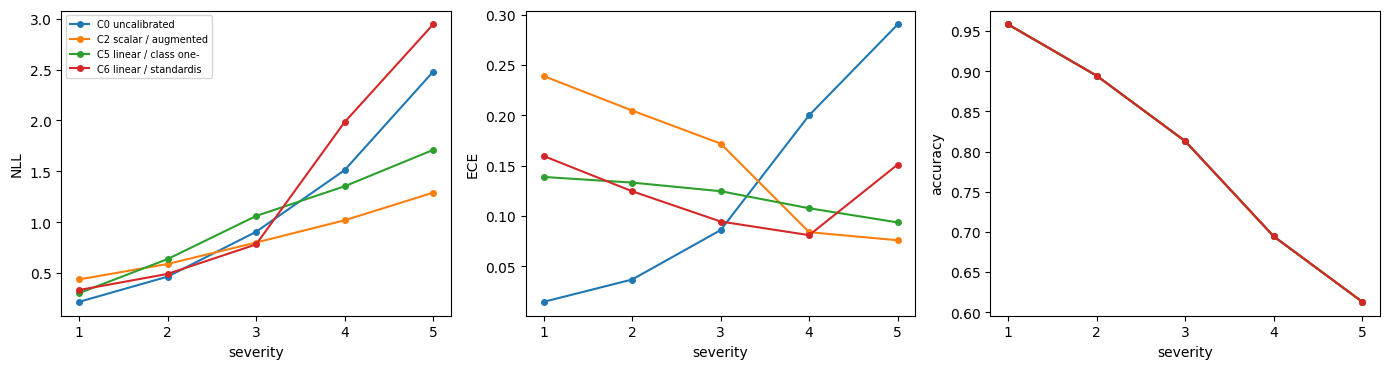

In [ ]:
#@title Degradation curves per calibrator
fig,ax=plt.subplots(1,3,figsize=(14,3.8))
for name in ["C0 uncalibrated","C2 scalar / augmented","C5 linear / class one-hot",
             "C6 linear / standardised q"]:
    nll,ece,acc=[],[],[]
    for s in SEVERITIES:
        conds=[(f,s) for f in TEST_FAMILIES]
        L,Q,Z,H,Y=pack(te,conds); Xf={"q":Q,"h":H,"z":Z}
        if name=="C0 uncalibrated": p=softmax(L)
        else:
            with torch.no_grad():
                p=softmax(CALS[name](torch.as_tensor(L,dtype=torch.float32),
                          torch.as_tensor(Xf[INPUT[name]],dtype=torch.float32)).numpy())
        nll.append(nll_per_image(p,Y).mean()); ece.append(ece_em(p,Y))
        acc.append((p.argmax(1)==Y).mean())
    for a,v,t in zip(ax,[nll,ece,acc],["NLL","ECE","accuracy"]):
        a.plot(SEVERITIES,v,marker="o",ms=4,label=name[:2]+name[2:22])
        a.set_xlabel("severity"); a.set_ylabel(t); a.set_xticks(SEVERITIES)
ax[0].legend(fontsize=7)
plt.tight_layout(); plt.savefig(OUT/"phase0_6_curves.png",dpi=200,bbox_inches="tight"); plt.show()

---

## How to read the outcome

**If the verdict supports the method**, C5 becomes one of the most important rows in the paper.
It is the control that separates "our temperature tracks image quality" from "our temperature
tracks the class". Without it the leakage audit result — 0.234 residual against 0.167 chance —
would give a reviewer an easy and correct objection.

**If C6 beats C2 but not C5**, the honest move is renaming, not deletion. A calibrator conditioned
on the predicted class is a real thing and has a literature; it is simply not what the paper
currently claims.

**If C6 does not beat C2**, that is a publishable negative result inside a benchmark paper: under
acquisition shift, a single scalar temperature fitted on augmented validation data is sufficient,
and the extra machinery does not earn its place. State it in the abstract. Reviewers respect a
paper that tests its own idea hard enough to falsify it far more than one that reports a 0.3%
gain with no control.

## What remains blocked regardless of the outcome

KSDD2 from the official ViCoS release, Magnetic Tile folds rebuilt without the discarded pHash
grouping, and the F1–F6 fixes applied to the main notebook. None of that is affected by this
result — but none of it can be skipped either.